In [1]:
import os
import sys
# Add parent directory to path for imports
try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()
sys.path.append(os.path.dirname(base_dir))
from utils.visualize import (load_metrics, plot_k_comparison, plot_best_models)

## Change dataset results folder names
+ fuzzy_model_name_BRdataset to biofuzzy_model_name_dataset

In [10]:
base_dir = "../results/two_classes/no_label_leakage"
def change_BRfolder_name(base_dir):
    for folder in os.listdir(base_dir):
        path = os.path.join(base_dir, folder)

        if not os.path.isdir(path):
            continue

        parts = folder.split("_")

        if len(parts) < 3:
            continue

        model_type = parts[0]
        dataset = parts[-1]
        model_name = '_'.join(parts[1:-1])
        #print(model_type, model_name, dataset)
        

        if dataset.startswith("BR"):
            new_dataset = dataset[2:]  # remove BR
            new_name = f"biofuzzy_{model_name}_{new_dataset}"
            #print(new_name)
            #break

            new_path = os.path.join(base_dir, new_name)

            print(f"{folder} -> {new_name}")
            os.rename(path, new_path)
    return

## Comparison of models performance on datatsets
+ datasets 
    + Composite
    + NormExpression
    + NormSubgraph
    + NormCluster
+ models
    + Baseline GNN models
    + biofuzzy: BioFuzzy rules with GNN models
    + fuzzy; Topological fuzzy rules with GNN models


In [2]:
# flat all metrics in a df
df_2cls_nll = load_metrics("../results/two_classes/no_label_leakage")

In [3]:
df_2cls_nll

,Accuracy,Precision,Recall,F1-Score,AUROC,model,modelType,modelName,dataset,k
150,0.621622,0.601294,0.621622,0.556446,0.575479,baseline_gat,baseline,gat,Composite,2
163,0.621622,0.638117,0.621622,0.510310,0.536782,baseline_gat,baseline,gat,Composite,3
165,0.635135,0.645800,0.635135,0.552383,0.514943,baseline_gat,baseline,gat,Composite,4
148,0.635135,0.771959,0.635135,0.518342,0.651724,baseline_gat,baseline,gat,Composite,5
142,0.621622,0.638117,0.621622,0.510310,0.604598,baseline_gat,baseline,gat,Composite,6
...,...,...,...,...,...,...,...,...,...,...
1398,0.986486,0.986780,0.986486,0.986442,0.998467,fuzzy_paper_gcn,fuzzy,paper_gcn,NormSubgraph,25
1389,0.972973,0.972973,0.972973,0.972973,0.998467,fuzzy_paper_gcn,fuzzy,paper_gcn,NormSubgraph,26
1373,0.959459,0.961993,0.959459,0.959008,1.000000,fuzzy_paper_gcn,fuzzy,paper_gcn,NormSubgraph,27
1393,0.932432,0.939189,0.932432,0.931023,1.000000,fuzzy_paper_gcn,fuzzy,paper_gcn,NormSubgraph,28


In [3]:
df_2cls_nll['dataset'].unique()

array(['Composite', 'NormCluster', 'NormExpression',
       'NormExpressionSubgraph', 'NormSubgraph'], dtype=object)

/home/xyu/thesis/FireGNN/utils/visualize.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_df, x='model', y=metric_name, palette='viridis')


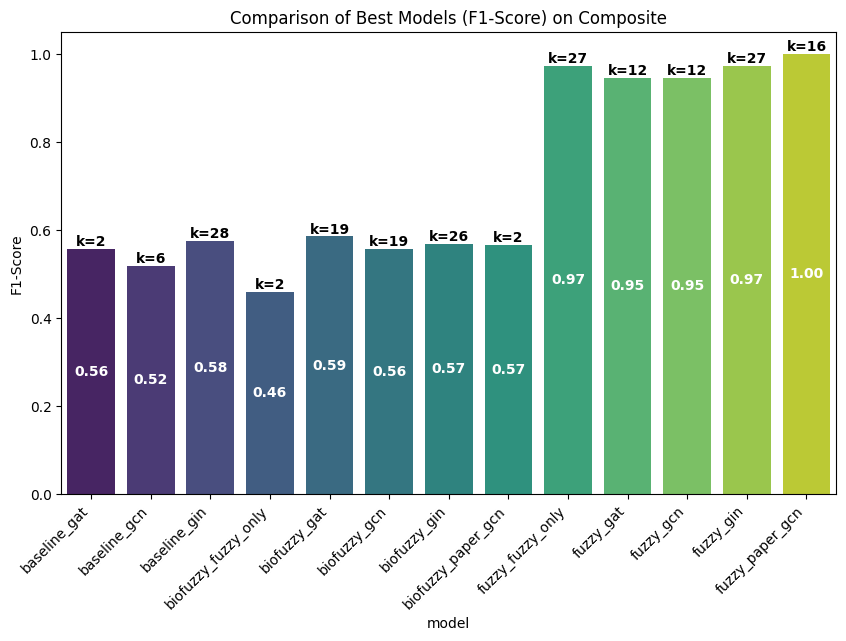

/home/xyu/thesis/FireGNN/utils/visualize.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_df, x='model', y=metric_name, palette='viridis')


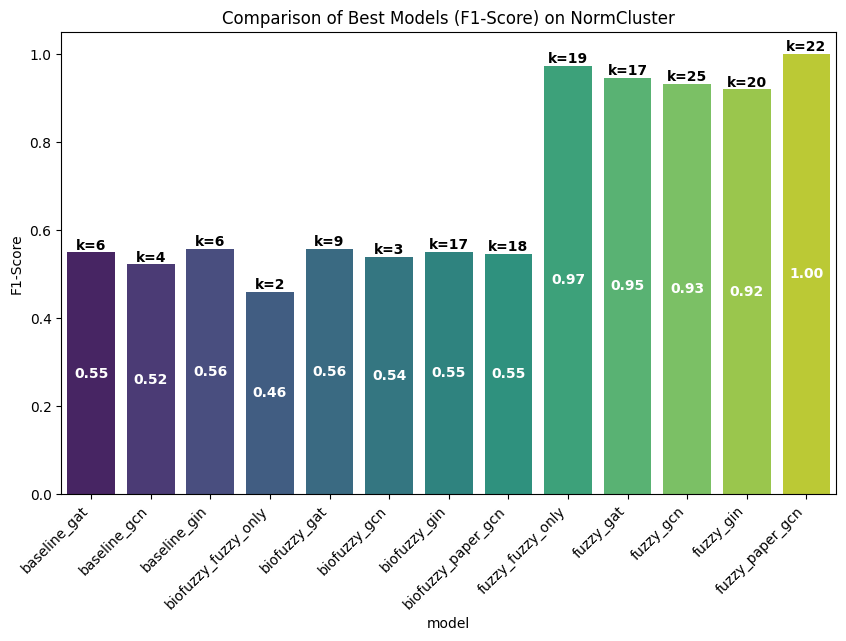

/home/xyu/thesis/FireGNN/utils/visualize.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_df, x='model', y=metric_name, palette='viridis')


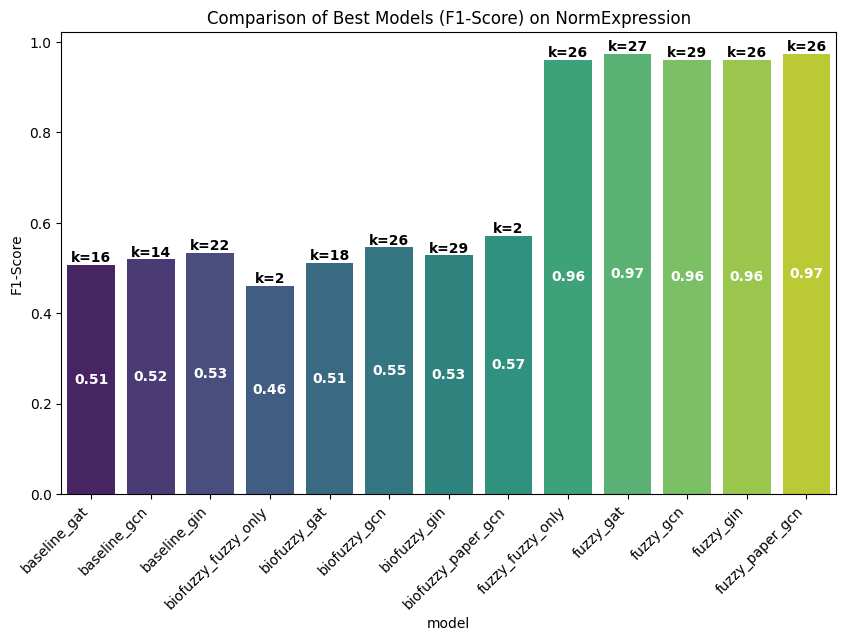

/home/xyu/thesis/FireGNN/utils/visualize.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_df, x='model', y=metric_name, palette='viridis')


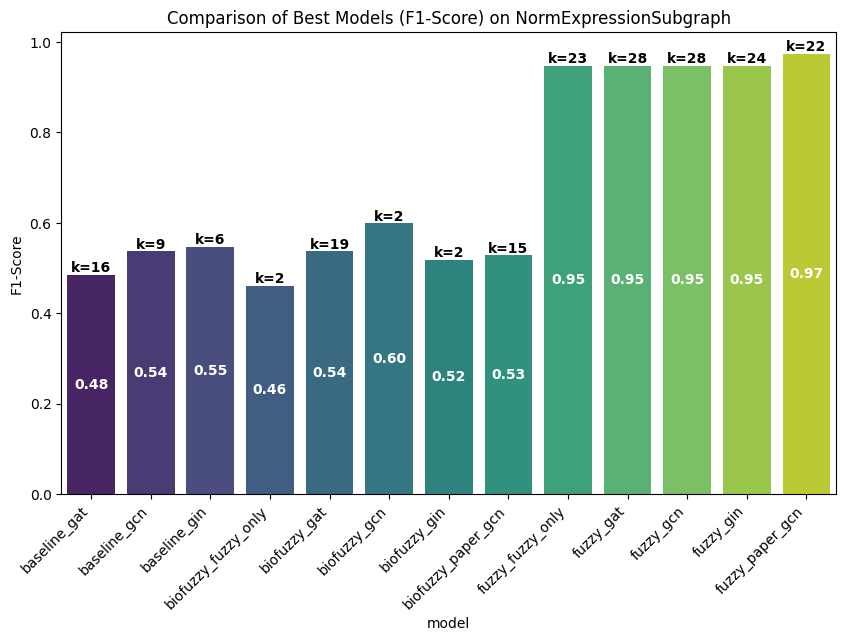

/home/xyu/thesis/FireGNN/utils/visualize.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_df, x='model', y=metric_name, palette='viridis')


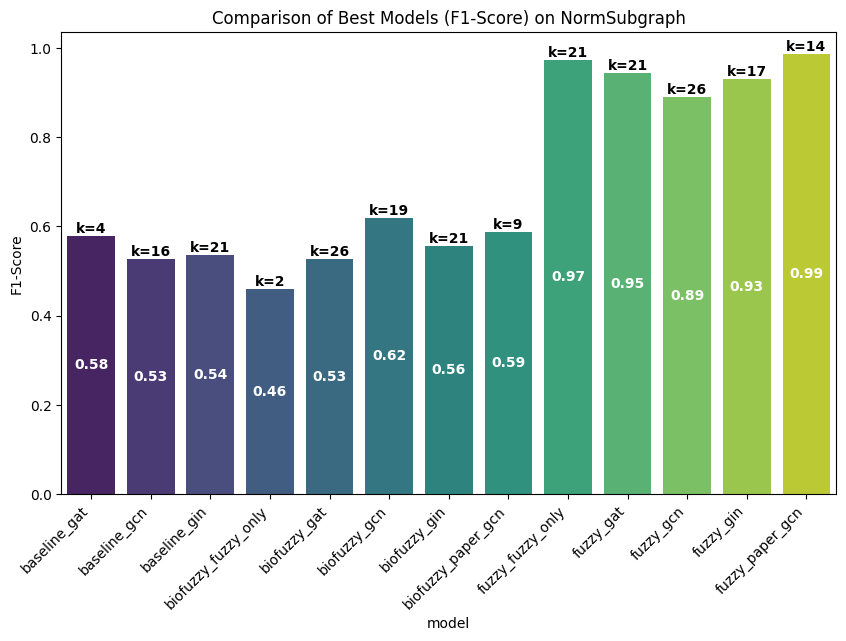

In [4]:
plot_best_models(df_2cls_nll, metric_name='F1-Score')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_dataset_comparison(df, metric_name='F1-Score', hue='modelType'):
    # Get best k for each model-dataset pair
    idx = df.groupby([hue, 'dataset'])[metric_name].idxmax()
    best_df = df.loc[idx]

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=best_df,
        x='dataset',
        y=metric_name,
        hue=hue,
        palette='viridis'
    )
    for container in plt.gca().containers:
        plt.bar_label(container, fmt="%.2f")

    plt.xticks(rotation=30, ha='right')
    plt.ylabel(metric_name)
    plt.title(f'{metric_name} Comparison Across Datasets')

    plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

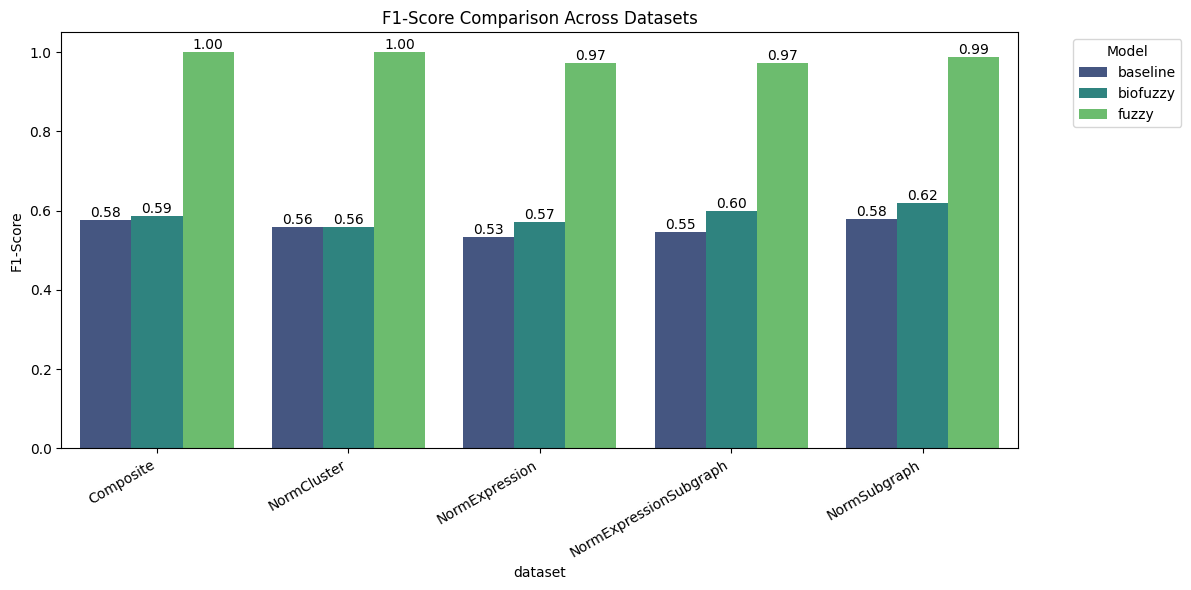

In [10]:
plot_dataset_comparison(df_2cls_nll)